# Model V7 — Budget-Scaled Response (V4 structure)

**Response variable:** trolleys per million-euro of HSE regional budget

$$y_{i,t} = \frac{\text{total\_trolleys}_{i,t}}{\text{budget}_i \,/\, 1000}$$

**Likelihood:**
$$y_{i,1} \sim \mathcal{N}(\mu_{i,1},\, \tau_i)$$
$$y_{i,t} \sim \mathcal{N}\Big(\mu_{i,t} + \phi\,(y_{i,t-1} - \mu_{i,t-1}),\, \tau_i\Big), \quad t = 2,\ldots,T$$

**Mean function (same structure as V4):**
$$\mu_{i,t} = \alpha_i + \beta_i \cos\Big(\frac{2\pi t}{52}\Big) + \gamma_i \sin\Big(\frac{2\pi t}{52}\Big) + $$
$$\delta_{\text{pre},i}\, \mathbb{1}(t\bmod 52 = 0) + \delta_{\text{mid},i}\, \mathbb{1}(t\bmod 52 = 1) + \delta_{\text{post},i}\, \mathbb{1}(t\bmod 52 = 2) + $$
$$\sigma_{\text{pre}}\, \mathbb{1}(t = 86, i=\text{mid west}) + \sigma_{\text{mid}}\, \mathbb{1}(t = 87, i=\text{mid west}) + \sigma_{\text{post}}\, \mathbb{1}(t = 88, i=\text{mid west})$$

**Hierarchical prior on intercept:**
$$\alpha_i \sim \mathcal{N}(\mu_\alpha,\; \tau_\alpha)$$

**Other priors:**
$$\beta_i, \gamma_i, \delta_{\text{pre},i}, \delta_{\text{mid},i}, \delta_{\text{post},i} \sim \mathcal{N}(0,\, 10^3) \quad \tau_i \sim \text{Gamma}(0.001,\, 0.001) \quad \phi \sim \text{Uniform}(-1,\, 1)$$
$$\sigma_{\text{pre}},\, \sigma_{\text{mid}},\, \sigma_{\text{post}} \sim \mathcal{N}(0,\, 10^3) \quad \mu_\alpha \sim \mathcal{N}(0,\, 10^3) \quad \tau_\alpha \sim \text{Gamma}(0.001,\, 0.001)$$

**Key difference from V4:** response variable is budget-scaled (trolleys per thousand-euro budget) rather than per-10k population.

In [1]:
from model_helpers import *

VERSION = 'v7'
PLOT_DIR = f'../../data/models/{VERSION}/plots/'
DATA_DIR = f'../../data/models/{VERSION}/'

df_og, raw_df, regions, n_region = load_model_data(
    VERSION, data_csv='../../data/wide_weekly_scaledPerBudgetThousands.csv'
)

## Load the model parameters

In [2]:
n_weeks = df_og.shape[1] - 1
ev = build_event_indicators(n_weeks, regions)
df_mu, df_mu_lower, df_mu_upper, phi_mean = reconstruct_mu(raw_df, regions, n_weeks, ev)

## Preprocess
Transpose the og df into regions (cols) x time (weeks)

In [3]:
df_og = transpose_observed(df_og)

## Make the model estimate df
Formula
y[i,t] ~ dnorm(mu[i,t] + (phi * (y[i,t-1] - mu[i,t-1])), tau[i])

In [4]:
df_ar1 = compute_ar1_fitted(df_mu, df_og, phi_mean)
df_ar1

,HSE Dublin and Midlands,HSE Dublin and North East,HSE Dublin and South East,HSE Mid West,HSE South West,HSE West and North West
0,0.131085,0.098584,0.138226,0.228057,0.218873,0.233357
1,0.180224,0.165023,0.191633,0.272205,0.266873,0.287461
2,0.154184,0.100575,0.153575,0.194386,0.17443,0.178891
3,0.149407,0.090139,0.132769,0.204175,0.19334,0.23054
4,0.129037,0.080416,0.135334,0.18941,0.213887,0.20209
...,...,...,...,...,...,...
165,0.106374,0.073959,0.151701,0.273429,0.211866,0.241853
166,0.115147,0.070654,0.111596,0.248007,0.238324,0.215244
167,0.096487,0.055877,0.13015,0.210469,0.232365,0.200438
168,0.102283,0.060162,0.110689,0.181082,0.185925,0.181201


## Plot MU
This should look like yearly oscillations

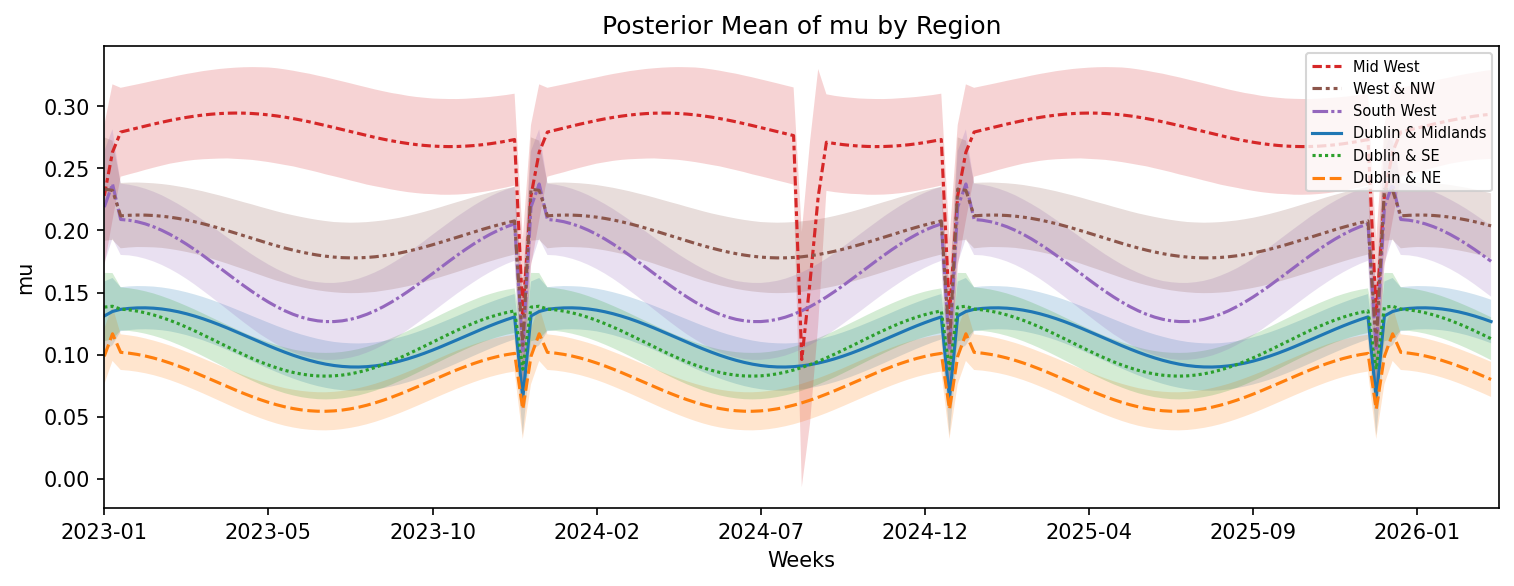

In [5]:
plot_mu(df_mu, df_mu_lower, df_mu_upper, PLOT_DIR + 'mu_fit.png')

## Plot model fit

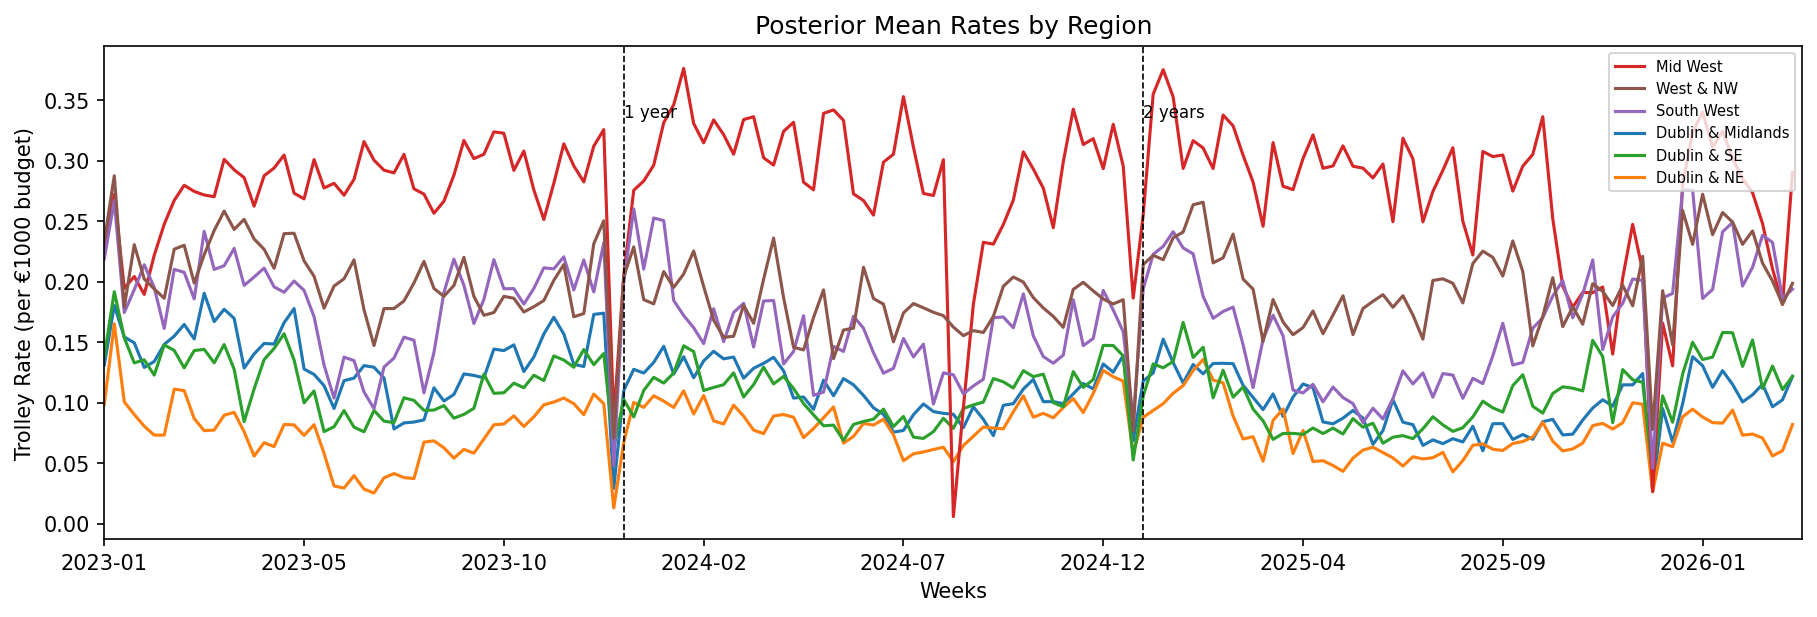

In [6]:
plot_ar1_fit(df_ar1, PLOT_DIR + 'ar1_fit.png',
             ylabel='Trolley Rate (per \u20ac1000 budget)')

## Plot the residuals

In [7]:
df_residuals, df_std_resid = compute_residuals(df_og, df_ar1)

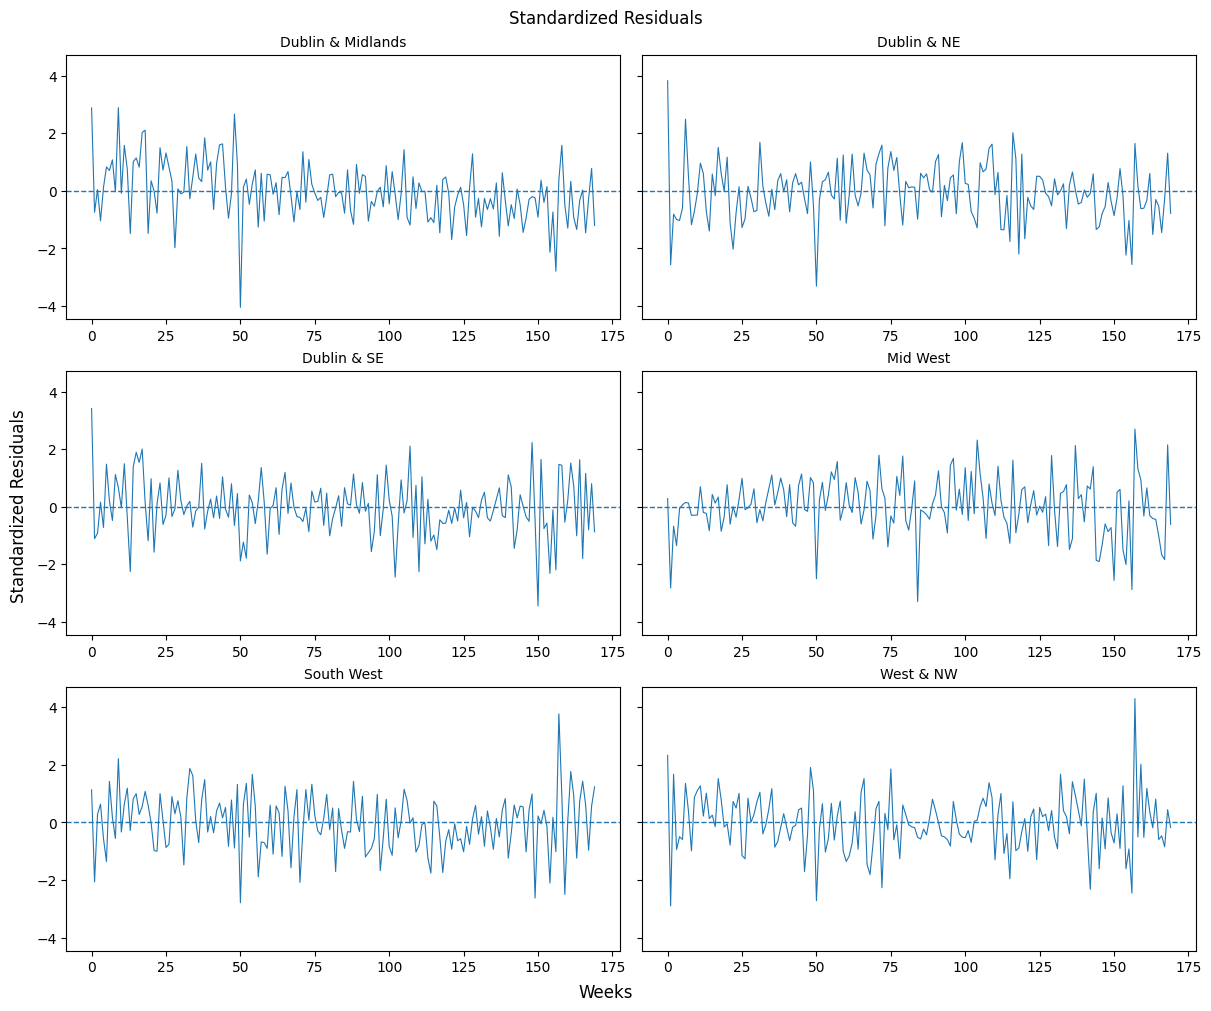

In [8]:
plot_residuals_ts(df_std_resid, PLOT_DIR + 'residuals_ts.png')

### Autocorrelation of Residuals

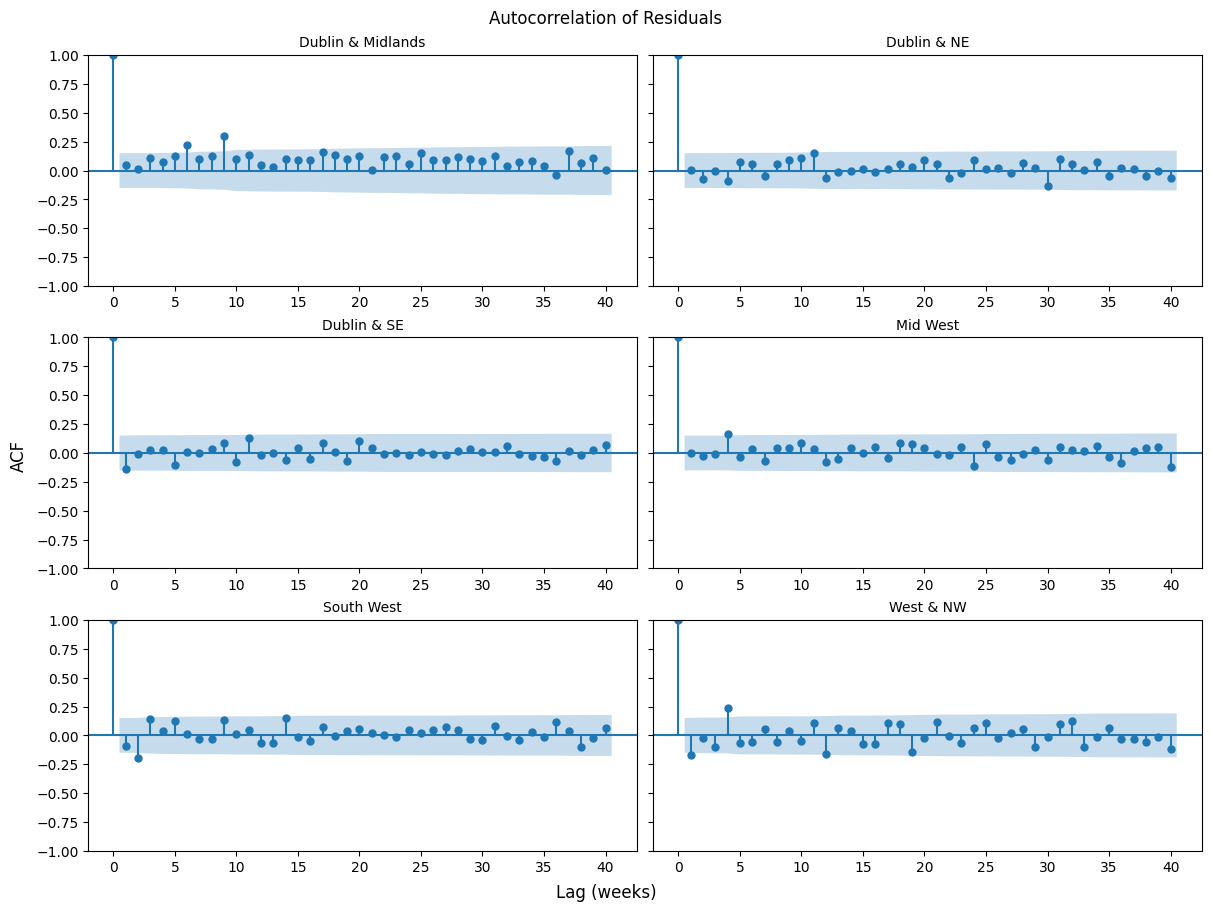

In [9]:
plot_residuals_acf(df_std_resid, PLOT_DIR + 'residuals_acf.png')

### Residuals vs Fitted

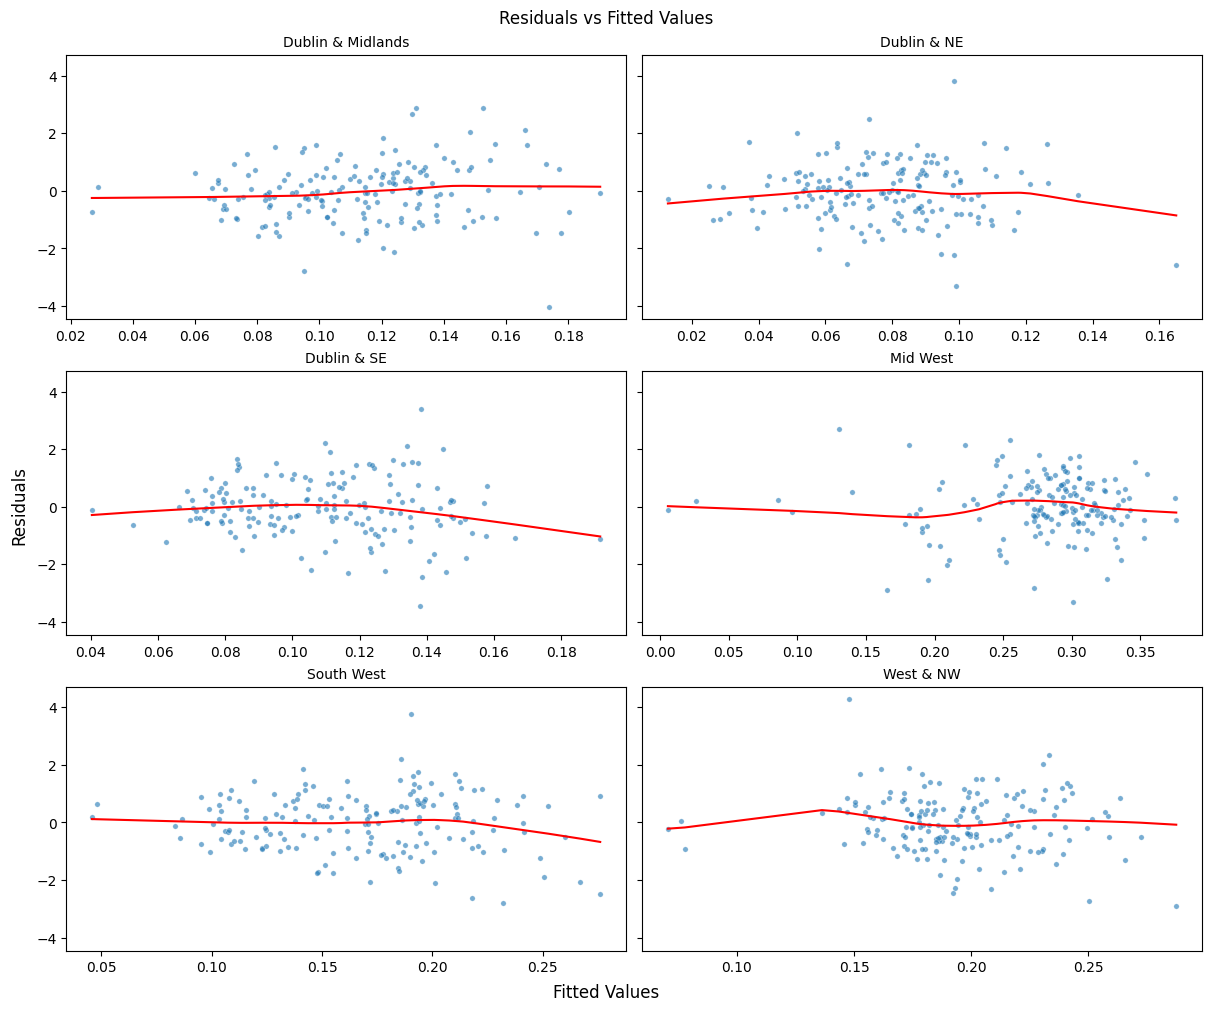

In [10]:
plot_residuals_vs_fitted(df_std_resid, df_ar1, PLOT_DIR + 'residuals_vs_fitted.png')

### QQ-Plot For Residuals

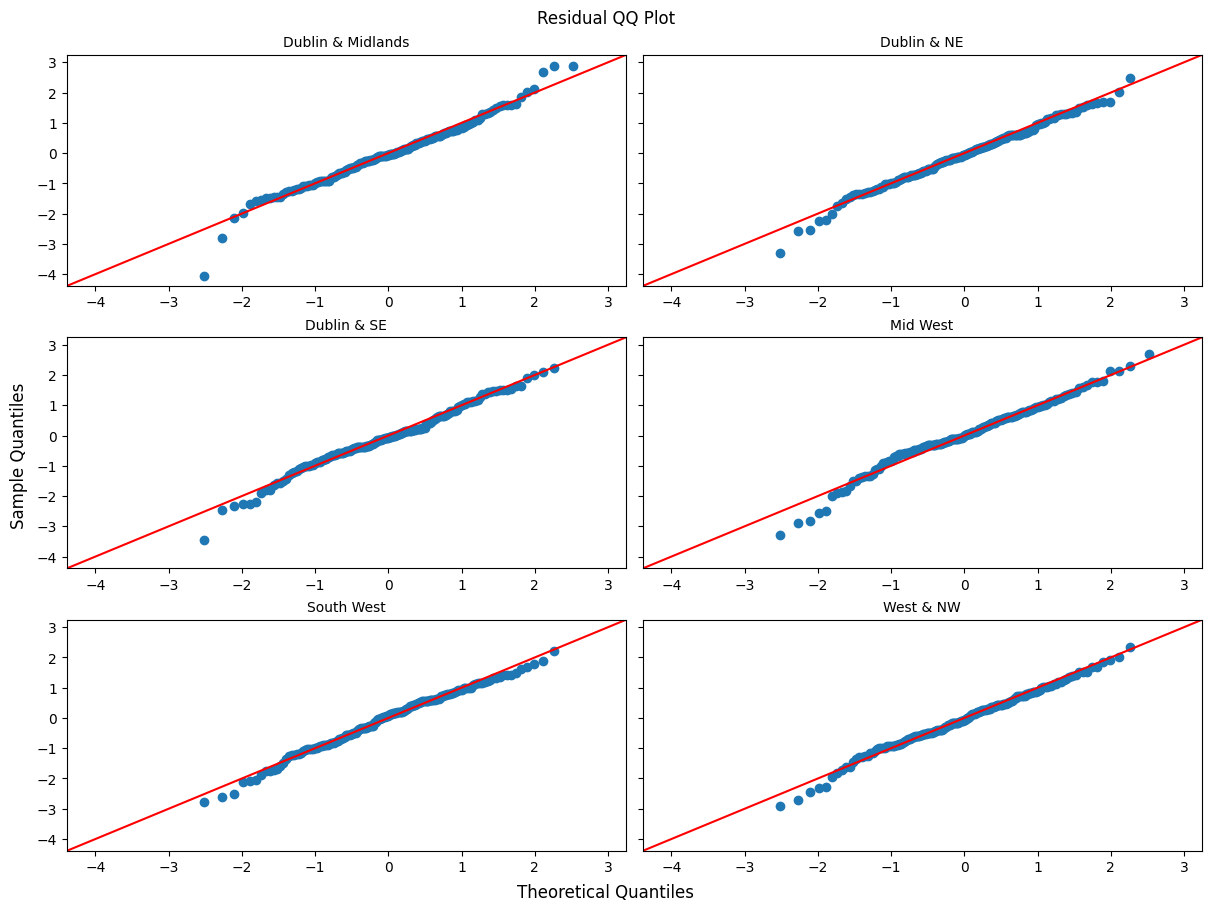

In [11]:
plot_residuals_qq(df_std_resid, PLOT_DIR + 'residuals_qq.png')

# Significance Testing

### Bonferroni correction

In [12]:
# Available via: calc_bonf(n_comparisons, one_sided=False)

### Annual cycle amplitude
$$\hat{A} = \sqrt{\beta^2 + \gamma^2}$$

- Tests whether the seasonal cycle has a practically meaningful magnitude
- $P(A_i > \varepsilon)$ where $\varepsilon = 0.5$ trolleys per \u20ac1000 budget
- No hypothesis test — direct posterior probability statement

In [13]:
ampl = compute_amplitude(raw_df, regions)

In [14]:
epsilon = 0.5

results = []
for region in regions:
    a = ampl[region]
    post_p = (a > epsilon).mean()
    results.append({
        'Region':        region,
        'Mean A':        round(a.mean(), 3),
        'Median A':      round(np.median(a), 3),
        '2.5%':          round(np.quantile(a, 0.025), 3),
        '97.5%':         round(np.quantile(a, 0.975), 3),
        f'P(A > {epsilon})': round(post_p, 3),
    })

df_ampl_overall = pd.DataFrame(results).sort_values(f'P(A > {epsilon})', ascending=False)
df_ampl_overall.to_csv(DATA_DIR + 'amplitude_overall.csv', index=False)
df_ampl_overall

,Region,Mean A,Median A,2.5%,97.5%,P(A > 0.5)
0,HSE Dublin and Midlands,0.025,0.025,0.011,0.040,0.0
1,HSE Dublin and North East,0.025,0.025,0.013,0.037,0.0
2,HSE Dublin and South East,0.028,0.028,0.014,0.043,0.0
3,HSE Mid West,0.023,0.021,0.004,0.049,0.0
4,HSE South West,0.043,0.043,0.020,0.067,0.0
5,HSE West and North West,0.021,0.021,0.005,0.042,0.0


### Annual cycle amplitude — pairwise

In [16]:
df_ampl_pw = pairwise_test(ampl, regions, epsilon=0.5)
df_ampl_pw.to_csv(DATA_DIR + 'amplitude_pairwise.csv', index=False)
df_ampl_pw

,Region A,Region B,MeanDiff,2.5%,97.5%,P(|diff| > 0.5),P(diff > 0),P(diff < 0)
0,HSE Dublin and Midlands,HSE Dublin and North East,0.000,-0.018,0.019,0.0,0.519,0.481
1,HSE Dublin and Midlands,HSE Dublin and South East,-0.003,-0.023,0.017,0.0,0.382,0.618
2,HSE Dublin and Midlands,HSE Mid West,0.002,-0.027,0.027,0.0,0.594,0.406
3,HSE Dublin and Midlands,HSE South West,-0.018,-0.045,0.010,0.0,0.098,0.902
4,HSE Dublin and Midlands,HSE West and North West,0.004,-0.021,0.026,0.0,0.628,0.372
5,HSE Dublin and North East,HSE Dublin and South East,-0.003,-0.022,0.015,0.0,0.356,0.644
6,HSE Dublin and North East,HSE Mid West,0.002,-0.026,0.025,0.0,0.587,0.413
7,HSE Dublin and North East,HSE South West,-0.018,-0.045,0.008,0.0,0.085,0.915
8,HSE Dublin and North East,HSE West and North West,0.003,-0.020,0.024,0.0,0.622,0.378
9,HSE Dublin and South East,HSE Mid West,0.005,-0.024,0.030,0.0,0.672,0.328


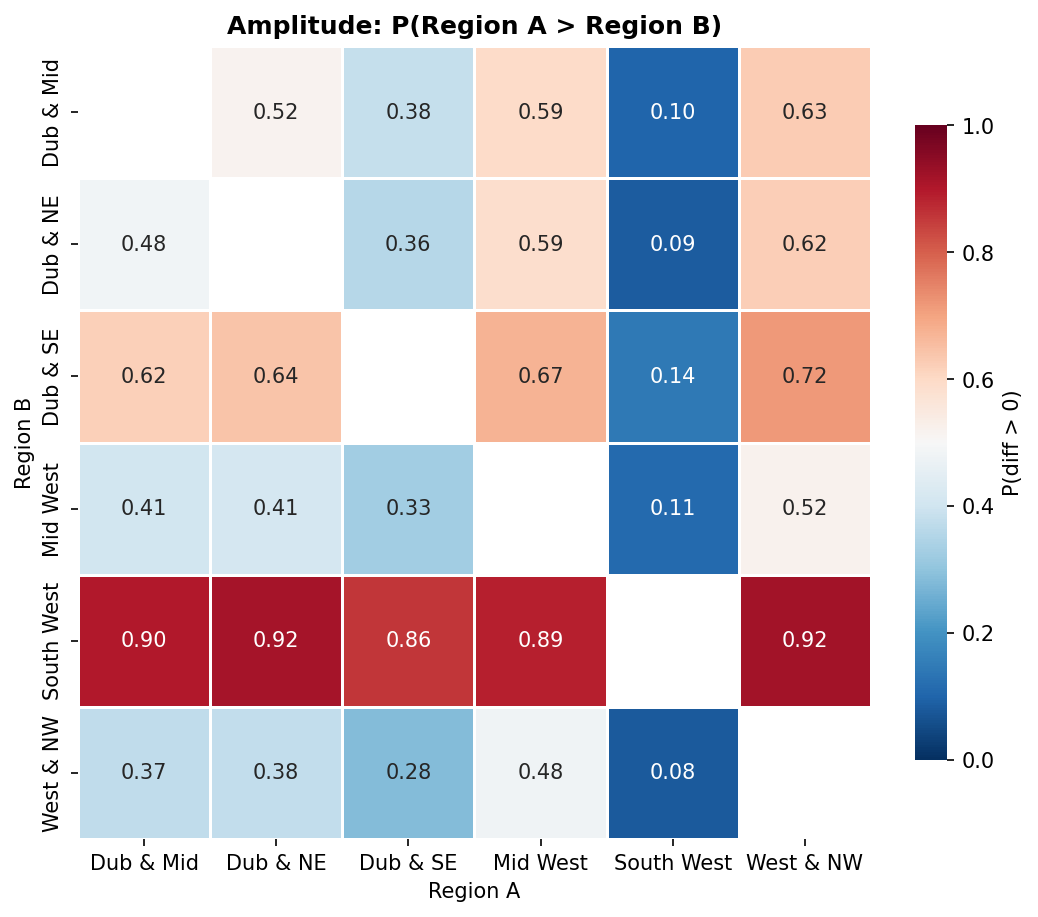

In [17]:
pairwise_heatmap(df_ampl_pw, 'P(diff > 0)',
                 'Amplitude: P(Region A > Region B)',
                 PLOT_DIR + 'amplitude_pairwise.png')

### Phase cycles — overall test

The seasonal component is $\beta_i \cos(\frac{2\pi t}{52}) + \gamma_i \sin(\frac{2\pi t}{52})$, which peaks when:

$$t_{\text{peak}} = \frac{52}{2\pi}\;\text{arctan2}(\gamma_i,\, \beta_i)$$

- We use `arctan2` instead of `arctan`
- `arctan(γ/β)` only returns values in $(-\pi/2,\, \pi/2)$ — it cannot distinguish which quadrant the angle falls in.
- This matters because $\beta$ and $\gamma$ can both be negative (peak in summer), and `arctan(γ/β)` would collapse that to the same angle as both positive (peak in winter).

### Peak week forest plot — winter band

#### Bayes Factors vs posterior probability

$$BF = \frac{\text{posterior odds}}{\text{prior odds}}$$

Phase winter test:

$$\text{prior odds} = \frac{P(\text{winter})}{P(\neg\text{winter})} = \frac{9/52}{43/52} = \frac{9}{43}$$

$$\text{posterior odds} = \frac{P(\text{winter} \mid \text{data})}{P(\neg\text{winter} \mid \text{data})}$$

### Phase cycles — flu season test
- Based on visual inspection of a distribution from Green et al. (2015), flu season in northern ireland was round 48-14 months
- This is somewhat arbitrary and can be formally inspected

In [18]:
flu_season_weeks    = (48, 14)
prior_winter        = (4+14) / 52
flu_key = f'{flu_season_weeks[0]} < phase < {flu_season_weeks[1]}'  
ci_lower_q, ci_upper_q = 0.025, 0.975


results = []
for i, region in enumerate(regions):
    b = raw_df[f'beta[{i+1}]'].values
    g = raw_df[f'gamma[{i+1}]'].values
    phase_rad = np.arctan2(g, b)
    peak_weeks = (52 / (2 * np.pi) * phase_rad) % 52
    mean_peak_wk = ((52 / (2 * np.pi)) * phase_rad.mean()) % 52
    median_peak_wk = ((52 / (2 * np.pi)) * np.median(phase_rad)) % 52

    prob_winter = ((peak_weeks >= flu_season_weeks[0]) | (peak_weeks <= flu_season_weeks[1])).mean()

    post_odds_w = prob_winter / max(1 - prob_winter, 1e-10)
    prior_odds_w = prior_winter / (1 - prior_winter)
    bf_winter = post_odds_w / prior_odds_w


    b = raw_df[f'beta[{i+1}]'].values
    g = raw_df[f'gamma[{i+1}]'].values
    phase = np.arctan2(g, b)
    lo_rad, hi_rad = np.quantile(phase, [ci_lower_q, ci_upper_q])
    mean_wk = ((52 / (2 * np.pi)) * phase.mean()) % 52
    lo_wk = ((52 / (2 * np.pi)) * lo_rad) % 52
    hi_wk = ((52 / (2 * np.pi)) * hi_rad) % 52
    ci_width = (hi_wk - lo_wk) % 52
    
    results.append({
        'Region': region,
        'Mean peak week': round(mean_peak_wk, 2),
        'Median peak week': round(median_peak_wk, 2),
        f'P({flu_key})': round(prob_winter, 3),
        '2.5%': round(lo_wk, 1),
        '97.5%': round(hi_wk, 1),
        'CI Width': round(ci_width, 1),
    })
df_season_phase_test = pd.DataFrame(results).sort_values(f'P({flu_key})', ascending=False)
df_season_phase_test.to_csv(DATA_DIR + 'seasonal_phase_test.csv', index=False)
df_season_phase_test

,Region,Mean peak week,Median peak week,P(48 < phase < 14),2.5%,97.5%,CI Width
0,HSE Dublin and Midlands,5.69,5.67,0.994,0.2,11.3,11.1
1,HSE Dublin and North East,1.62,1.60,0.994,49.4,6.0,8.6
2,HSE Dublin and South East,1.96,1.95,0.993,49.4,6.7,9.3
4,HSE South West,2.53,2.51,0.991,49.4,7.9,10.4
5,HSE West and North West,5.02,5.23,0.858,42.0,18.1,28.1
3,HSE Mid West,8.69,13.63,0.329,27.3,24.9,49.7


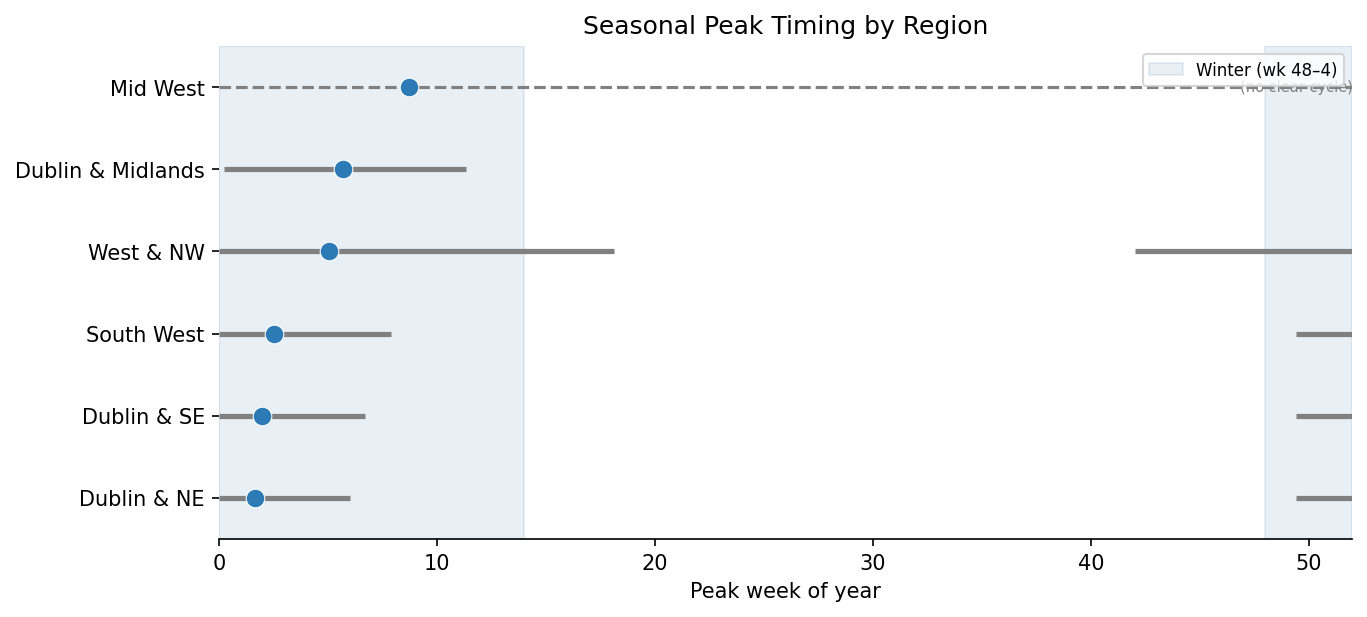

In [19]:
flu_season_weeks = (48, 14)

df_plot = df_season_phase_test.sort_values('Mean peak week')
lo_wk = df_plot['2.5%'].values
hi_wk = df_plot['97.5%'].values

def ci_width(lo, hi):
    return (hi - lo) % 52

fig, ax = plt.subplots(figsize=(9, 4), dpi=150, layout='constrained')
y_pos = list(range(len(df_plot)))

ax.axvspan(flu_season_weeks[0], 52, alpha=0.12, color='steelblue', label='Winter (wk 48\u20134)')
ax.axvspan(0, flu_season_weeks[1], alpha=0.12, color='steelblue')

for y, lo, hi, region in zip(y_pos, lo_wk, hi_wk, df_plot['Region'].values):
    width = ci_width(lo, hi)
    if width > 40:
        style = dict(color='grey', linewidth=1.5, linestyle='--', zorder=1)
        ax.hlines(y, 0, 52, **style)
        ax.annotate('(no clear cycle)', xy=(52, y), fontsize=7,
                    color='grey', va='center', ha='right')
    elif lo <= hi:
        ax.hlines(y, lo, hi, color='grey', linewidth=2.5, zorder=2)
    else:
        ax.hlines(y, lo, 52, color='grey', linewidth=2.5, zorder=2)
        ax.hlines(y, 0, hi, color='grey', linewidth=2.5, zorder=2)

ax.scatter(df_plot['Mean peak week'].values, y_pos, s=80, zorder=3,
           color='#2c7bb6', edgecolors='white', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels([SHORT_NAMES.get(r, r) for r in df_plot['Region'].values])
ax.set_xlabel('Peak week of year')
ax.set_xlim(0, 52)
ax.set_ylim(-0.5, len(y_pos) - 0.5)
ax.set_title('Seasonal Peak Timing by Region')
ax.legend(loc='upper right', fontsize=8)
sns.despine(left=True)
fig.savefig(PLOT_DIR + 'seasonal_phase_test.png', bbox_inches='tight', dpi=150)
plt.show()

## Alpha baseline
Global parameter summaries, regional map, and credible intervals for the region intercepts.

In [20]:
global_params = {
    'mu_alpha':  raw_df['mu_alpha'].values,
    'phi':       raw_df['phi'].values,
}

rows = []
for name, vals in global_params.items():
    rows.append({
        'Parameter': name,
        'Mean':      vals.mean(),
        'SD':        vals.std(),
        '2.5%':      np.quantile(vals, 0.025),
        '97.5%':     np.quantile(vals, 0.975),
    })

df_global = pd.DataFrame(rows).round(4)
df_global.to_csv(DATA_DIR + 'global_parameters.csv', index=False)
df_global

,Parameter,Mean,SD,2.5%,97.5%
0,mu_alpha,0.1578,0.0408,0.0778,0.2391
1,phi,0.6476,0.0278,0.5933,0.7020


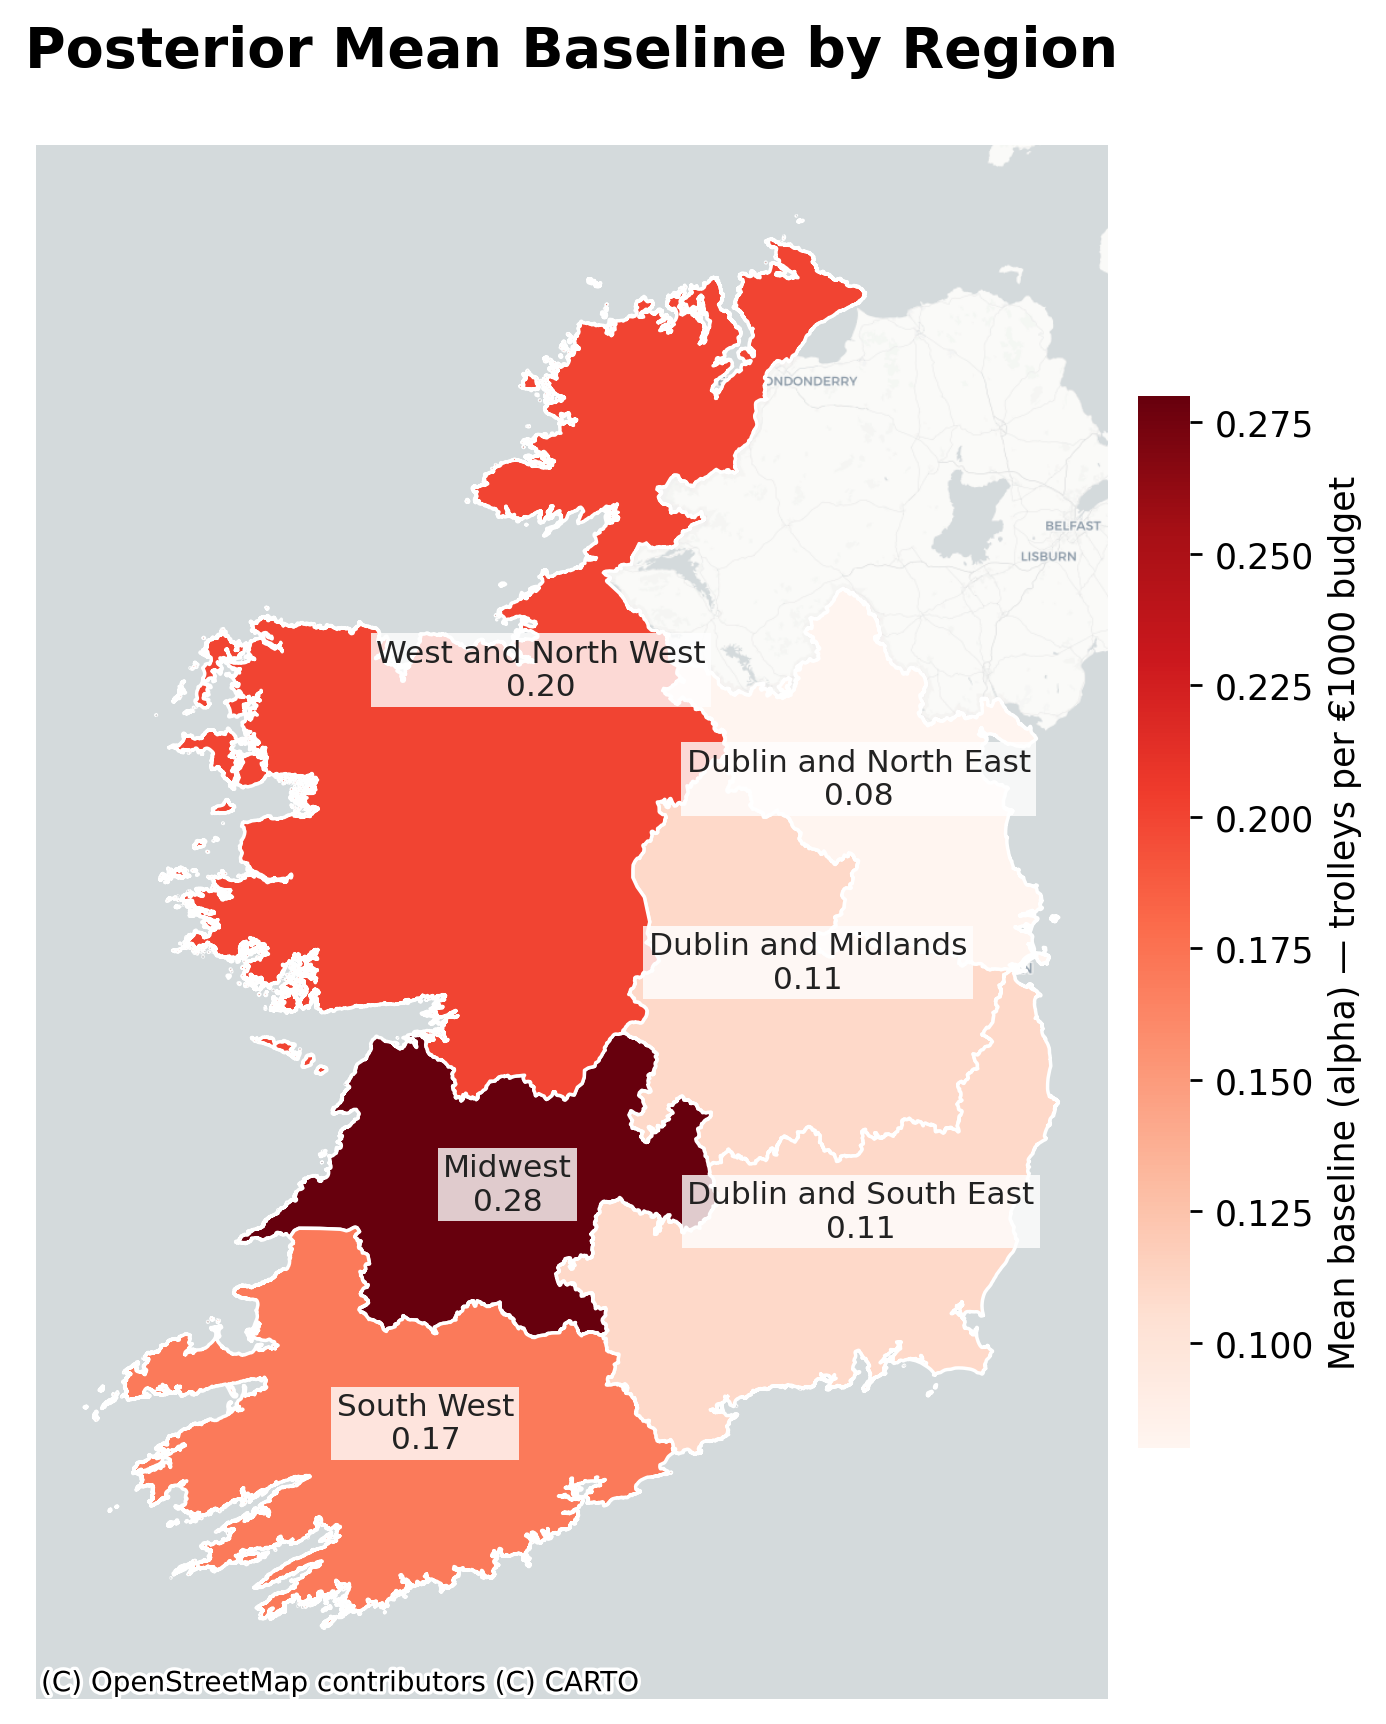

In [21]:
import geopandas as gpd
import matplotlib as mpl
import contextily as ctx

alpha_means = pd.DataFrame({
    'Region': regions,
    'mean_alpha': [raw_df[f'alpha[{i+1}]'].mean() for i in range(n_region)]
})
alpha_means['mean_alpha'] = alpha_means['mean_alpha'].round(2)

name_map = {
    'HSE Dublin and Midlands': 'HSE Dublin and Midlands HR',
    'HSE Dublin and North East': 'HSE Dublin and North East HR',
    'HSE Dublin and South East': 'HSE Dublin and South East HR',
    'HSE Mid West': 'HSE Midwest HR',
    'HSE South West': 'HSE South West HR',
    'HSE West and North West': 'HSE West and North West HR',
}
alpha_means['HR_operational_name'] = alpha_means['Region'].map(name_map)

gdf = gpd.read_file('../../data/mapping/hse_regions.geojson')
if gdf.crs is None:
    gdf = gdf.set_crs('EPSG:4326')
gdf = gdf.merge(alpha_means[['HR_operational_name', 'mean_alpha']], on='HR_operational_name', how='left')
gdf_3857 = gdf.to_crs(epsg=3857)
gdf_3857['label_point'] = gdf_3857.geometry.representative_point()

fig, ax = plt.subplots(figsize=(7, 7), dpi=250)
cmap = mpl.cm.Reds
vmin, vmax = float(gdf_3857['mean_alpha'].min()), float(gdf_3857['mean_alpha'].max())
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

gdf_3857.plot(column='mean_alpha', ax=ax, cmap=cmap, norm=norm, edgecolor='white', linewidth=1.0)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
except Exception as e:
    print(f'Basemap skipped: {e}')

for _, row in gdf_3857.iterrows():
    if pd.isna(row['mean_alpha']):
        continue
    x, y = row['label_point'].x, row['label_point'].y
    short = row['HR_operational_name'].replace(' HR', '').replace('HSE ', '')
    label = f"{short}\n{row['mean_alpha']:.2f}"
    ax.text(x, y, label, ha='center', va='center', fontsize=9, color='#222',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.5), zorder=5)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Mean baseline (alpha) \u2014 trolleys per \u20ac1000 budget', fontsize=10)
cbar.outline.set_visible(False)

ax.set_title('Posterior Mean Baseline by Region', fontsize=16, pad=12, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
fig.savefig(PLOT_DIR + 'alpha_overall.png', bbox_inches='tight', dpi=150)
plt.show()

In [22]:
results = []
for i, region in enumerate(regions):
    vals = raw_df[f'alpha[{i+1}]'].values
    ci_lower, ci_upper = np.quantile(vals, [0.025, 0.975])
    results.append({
        'Region':     region,
        'Mean':       vals.mean(),
        'Median':     np.median(vals),
        'SD':         vals.std(),
        '2.5%':       ci_lower,
        '97.5%':      ci_upper,
    })

df_alpha_overall = pd.DataFrame(results).sort_values('Mean', ascending=False).round(3)
df_alpha_overall.to_csv(DATA_DIR + 'alpha_overall.csv', index=False)
df_alpha_overall

,Region,Mean,Median,SD,2.5%,97.5%
3,HSE Mid West,0.281,0.281,0.011,0.259,0.303
5,HSE West and North West,0.195,0.195,0.008,0.179,0.212
4,HSE South West,0.168,0.168,0.009,0.150,0.186
0,HSE Dublin and Midlands,0.114,0.114,0.006,0.103,0.125
2,HSE Dublin and South East,0.110,0.110,0.005,0.099,0.120
1,HSE Dublin and North East,0.078,0.078,0.004,0.069,0.087


### Alpha baseline — overall test
$$H_0: \\alpha_i = 0 \\quad H_a: \\alpha_i \\neq 0$$

Tests whether each region's baseline trolley rate is significantly different from zero.

### Alpha baseline — pairwise test
Tests on $\\alpha_i$ directly (the region intercepts).

In [23]:
alpha_samples = {regions[i]: raw_df[f'alpha[{i+1}]'].values for i in range(n_region)}
df_alpha_pw = pairwise_test(alpha_samples, regions)
df_alpha_pw.to_csv(DATA_DIR + 'alpha_pairwise.csv', index=False)
df_alpha_pw

,Region A,Region B,MeanDiff,2.5%,97.5%,P(|diff| > 0.5),P(diff > 0),P(diff < 0)
0,HSE Dublin and Midlands,HSE Dublin and North East,0.036,0.022,0.050,0.0,1.000,0.000
1,HSE Dublin and Midlands,HSE Dublin and South East,0.004,-0.011,0.019,0.0,0.703,0.297
2,HSE Dublin and Midlands,HSE Mid West,-0.167,-0.192,-0.142,0.0,0.000,1.000
3,HSE Dublin and Midlands,HSE South West,-0.054,-0.075,-0.033,0.0,0.000,1.000
4,HSE Dublin and Midlands,HSE West and North West,-0.081,-0.101,-0.062,0.0,0.000,1.000
5,HSE Dublin and North East,HSE Dublin and South East,-0.032,-0.045,-0.018,0.0,0.000,1.000
6,HSE Dublin and North East,HSE Mid West,-0.203,-0.227,-0.179,0.0,0.000,1.000
7,HSE Dublin and North East,HSE South West,-0.090,-0.109,-0.070,0.0,0.000,1.000
8,HSE Dublin and North East,HSE West and North West,-0.117,-0.135,-0.099,0.0,0.000,1.000
9,HSE Dublin and South East,HSE Mid West,-0.171,-0.196,-0.146,0.0,0.000,1.000


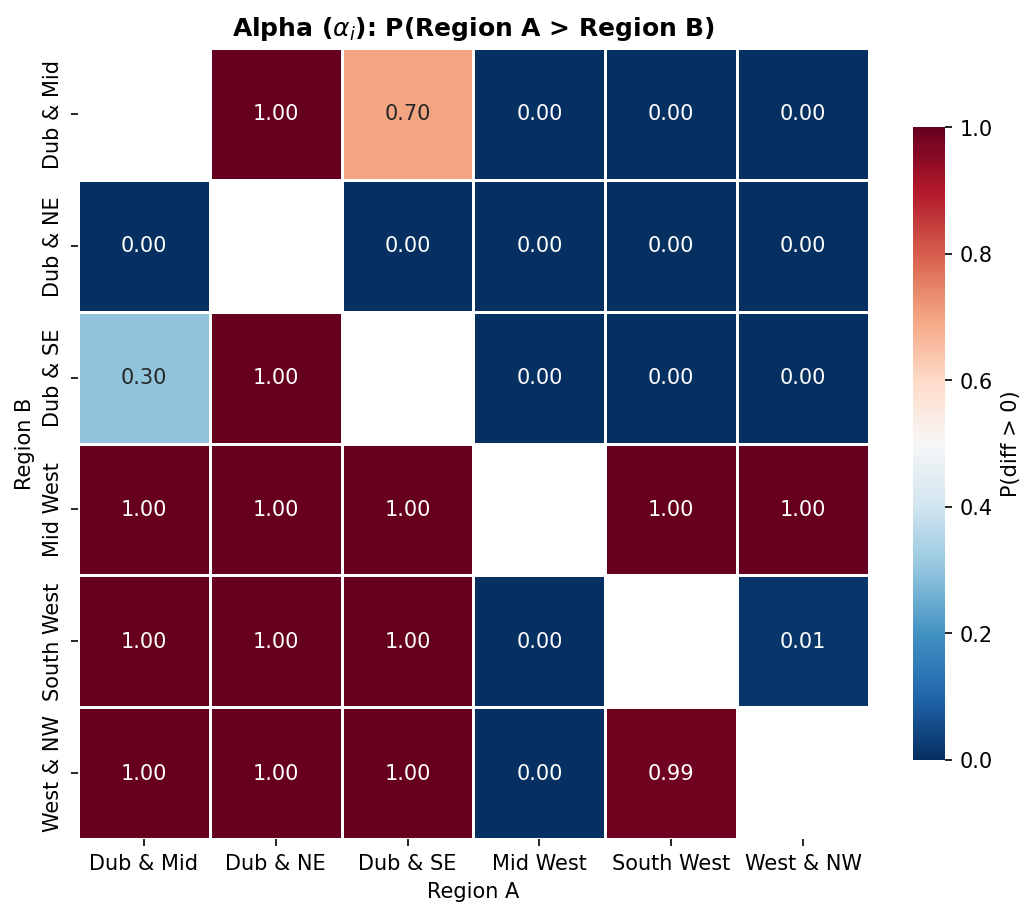

In [24]:
pairwise_heatmap(df_alpha_pw, 'P(diff > 0)',
                 r'Alpha ($\alpha_i$): P(Region A > Region B)',
                 PLOT_DIR + 'alpha_pairwise.png')

### New Year — delta (per-region)
V7 fits `delta_pre[i]`, `delta_mid[i]`, `delta_post[i]` per region (same structure as V4).

In [25]:
delta_params = ['delta_pre', 'delta_mid', 'delta_post']
delta_samples = {}
for param in delta_params:
    delta_samples[param] = {}
    for i in range(n_region):
        delta_samples[param][regions[i]] = raw_df[f'{param}[{i+1}]'].values

In [26]:
for param in delta_params:
    results = []
    for region in regions:
        vals = delta_samples[param][region]
        ci_lower, ci_upper = np.quantile(vals, [0.025, 0.975])
        results.append({
            'Region': region, 'Mean': vals.mean(),
            '2.5%': ci_lower,
            '97.5%': ci_upper,
            'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
        })
    df_sig = pd.DataFrame(results).sort_values('Mean', ascending=False).round(3)
    print(f'\n=== Overall: {param} ===')
    display(df_sig)
    df_sig.to_csv(DATA_DIR + f'delta_overall_{param}.csv', index=False)

delta_combined_rows = []
for param in delta_params:
    df_part = pd.read_csv(DATA_DIR + f'delta_overall_{param}.csv')
    df_part.insert(0, 'Parameter', param.replace('delta_', '').title())
    delta_combined_rows.append(df_part)
df_delta_combined = pd.concat(delta_combined_rows, ignore_index=True)
df_delta_combined.to_csv(DATA_DIR + 'delta_overall_combined.csv', index=False)


=== Overall: delta_pre ===


,Region,Mean,2.5%,97.5%,Sig
1,HSE Dublin and North East,-0.046,-0.068,-0.024,Yes
2,HSE Dublin and South East,-0.048,-0.074,-0.021,Yes
0,HSE Dublin and Midlands,-0.068,-0.095,-0.040,Yes
5,HSE West and North West,-0.102,-0.142,-0.061,Yes
4,HSE South West,-0.104,-0.148,-0.060,Yes
3,HSE Mid West,-0.142,-0.197,-0.087,Yes



=== Overall: delta_mid ===


,Region,Mean,2.5%,97.5%,Sig
5,HSE West and North West,0.023,-0.017,0.064,No
4,HSE South West,0.011,-0.034,0.055,No
2,HSE Dublin and South East,0.002,-0.025,0.028,No
0,HSE Dublin and Midlands,-0.003,-0.030,0.024,No
1,HSE Dublin and North East,-0.003,-0.025,0.018,No
3,HSE Mid West,-0.048,-0.103,0.007,No



=== Overall: delta_post ===


,Region,Mean,2.5%,97.5%,Sig
4,HSE South West,0.029,-0.011,0.069,No
5,HSE West and North West,0.021,-0.015,0.057,No
1,HSE Dublin and North East,0.015,-0.005,0.034,No
2,HSE Dublin and South East,0.002,-0.022,0.026,No
0,HSE Dublin and Midlands,-0.001,-0.025,0.023,No
3,HSE Mid West,-0.015,-0.064,0.035,No


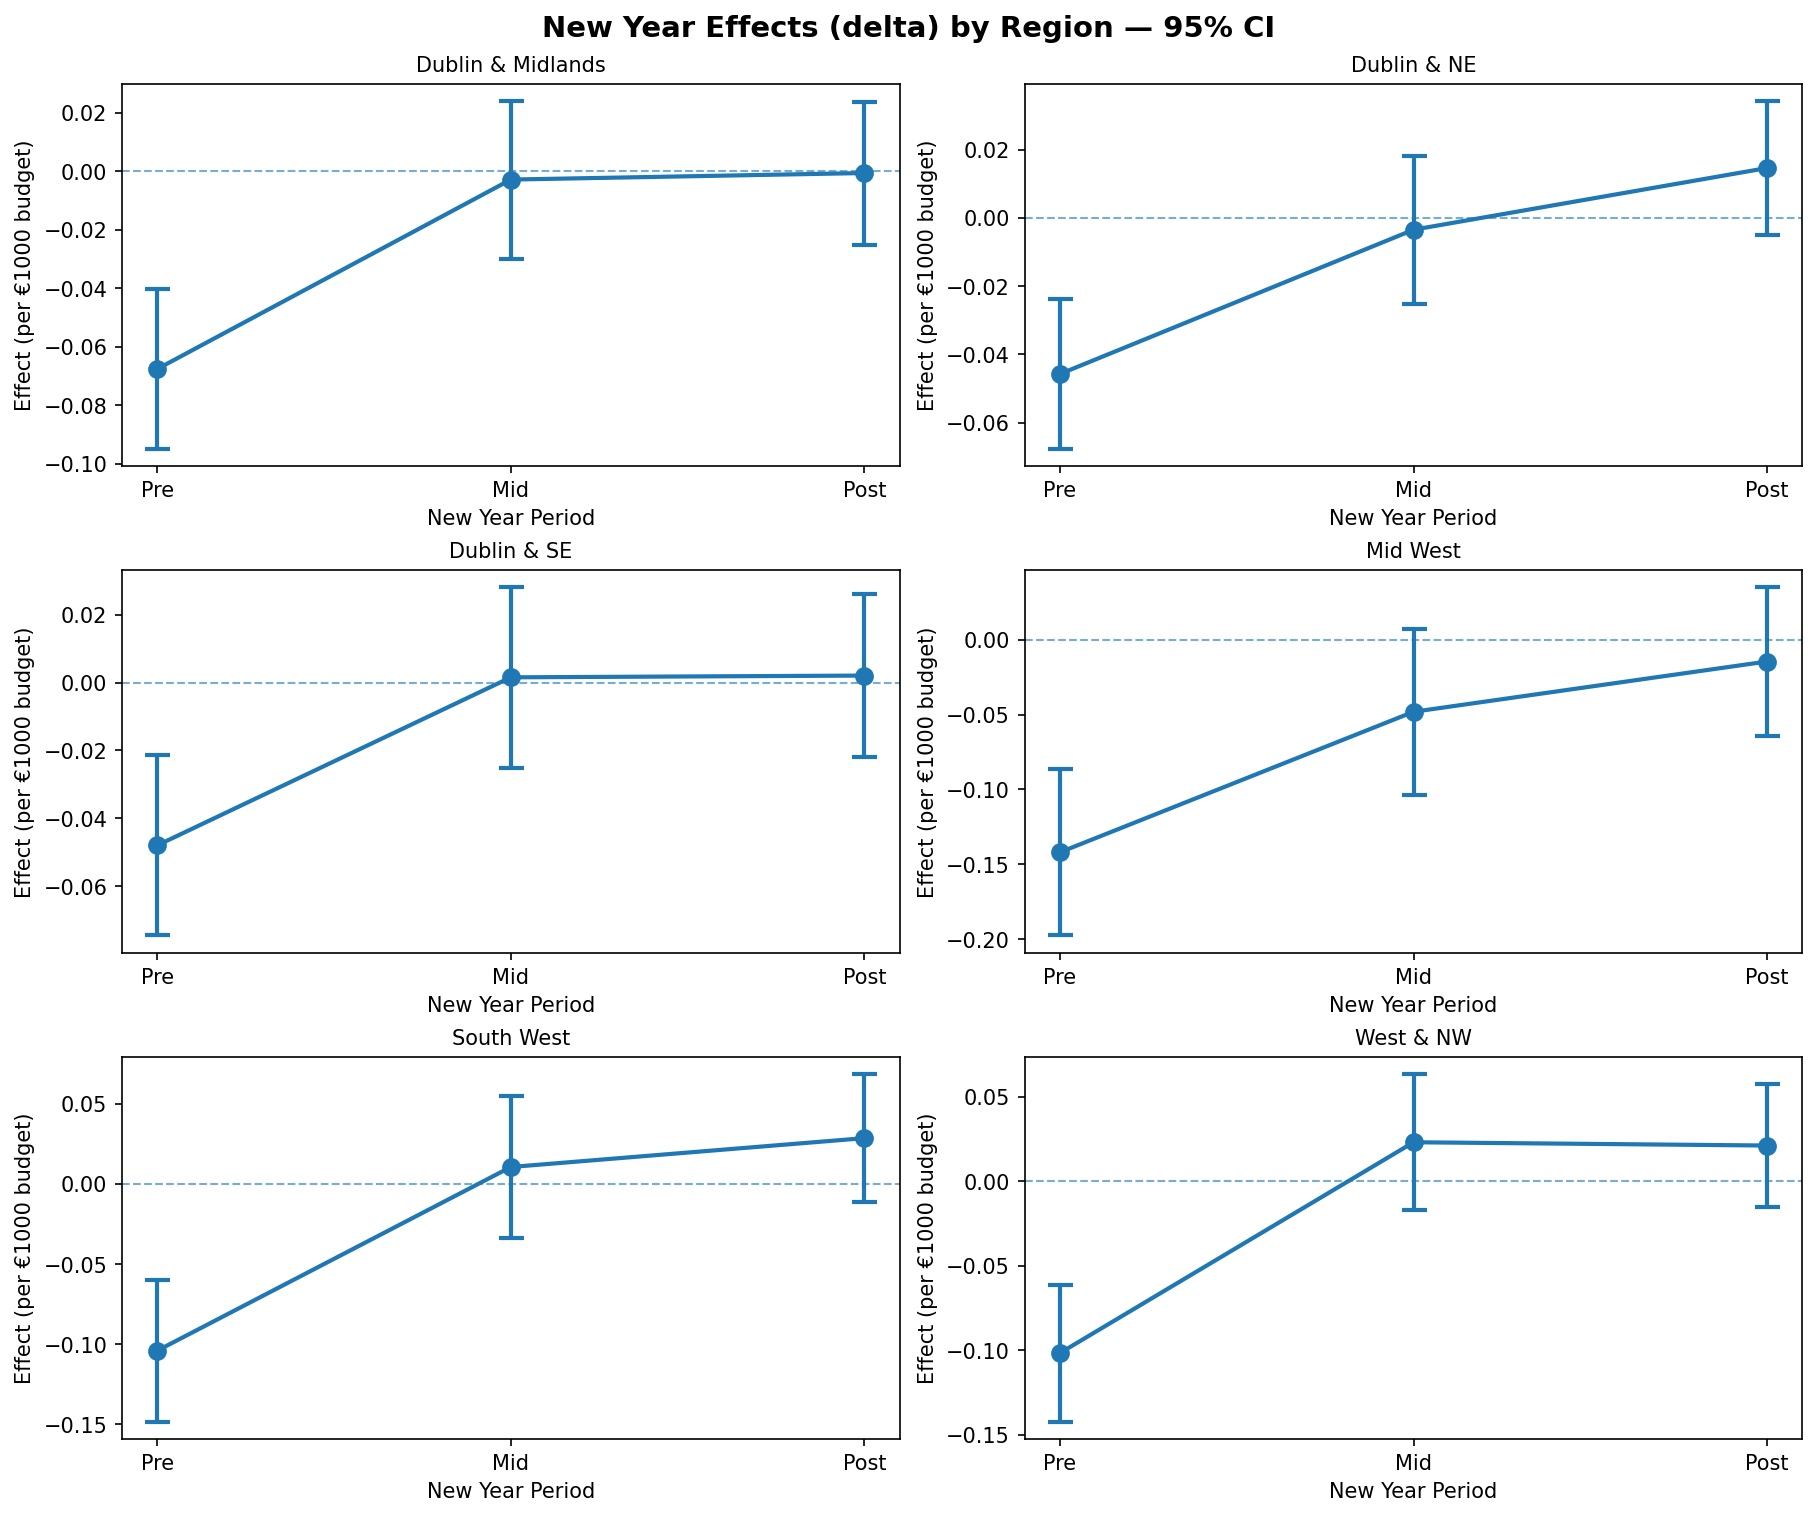

In [27]:
labels_nice = {'delta_pre': 'Pre', 'delta_mid': 'Mid', 'delta_post': 'Post'}
x_labels = [labels_nice[p] for p in delta_params]

fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=150, layout='constrained')
for idx, (region, ax) in enumerate(zip(regions, axes.flatten())):
    means  = np.array([delta_samples[p][region].mean() for p in delta_params])
    ci_lo  = np.array([np.quantile(delta_samples[p][region], 0.025) for p in delta_params])
    ci_hi  = np.array([np.quantile(delta_samples[p][region], 0.975) for p in delta_params])
    ax.errorbar(x_labels, means, yerr=[means - ci_lo, ci_hi - means],
                fmt='o-', linewidth=2, markersize=8, capsize=6, capthick=2, elinewidth=2, zorder=3)
    ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)
    ax.set_title(SHORT_NAMES.get(region, region), fontsize=10)
    ax.set_xlabel('New Year Period')
    ax.set_ylabel('Effect (per \u20ac1000 budget)')
fig.suptitle('New Year Effects (delta) by Region \u2014 95% CI', fontsize=14, fontweight='bold')
fig.savefig(PLOT_DIR + 'delta_overall_combined.png', bbox_inches='tight', dpi=150)
plt.show()

### Full Reset — sigma (global, Mid West only)

In [29]:
sigma_samples_global = raw_df[['sigma_pre', 'sigma_mid', 'sigma_post']]
sigma_params = ['sigma_pre', 'sigma_mid', 'sigma_post']

results = []
for param in sigma_params:
    vals = sigma_samples_global[param]
    ci_lower, ci_upper = np.quantile(vals, [0.025, 0.975])
    results.append({
        'Parameter': param, 'Mean': vals.mean(),
        '2.5%': ci_lower,
        '97.5%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })

df_sigma_ind = pd.DataFrame(results).round(3)
df_sigma_ind.to_csv(DATA_DIR + 'full_reset_overall.csv', index=False)
df_sigma_ind

,Parameter,Mean,2.5%,97.5%,Sig
0,sigma_pre,-0.179,-0.278,-0.080,Yes
1,sigma_mid,-0.115,-0.227,-0.005,Yes
2,sigma_post,-0.045,-0.144,0.054,No


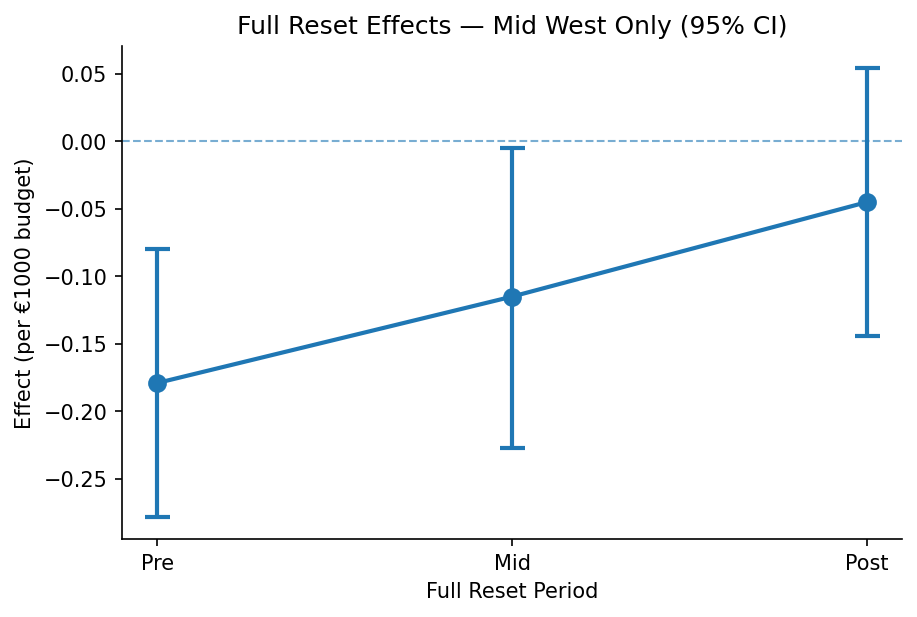

In [30]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150, layout='constrained')
ax.errorbar(['Pre', 'Mid', 'Post'], df_sigma_ind['Mean'].values,
            yerr=[df_sigma_ind['Mean'].values - df_sigma_ind['2.5%'].values,
                  df_sigma_ind['97.5%'].values - df_sigma_ind['Mean'].values],
            fmt='o-', linewidth=2, markersize=8,
            capsize=6, capthick=2, elinewidth=2, zorder=3)
ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Full Reset Period')
ax.set_ylabel('Effect (per \u20ac1000 budget)')
ax.set_title('Full Reset Effects \u2014 Mid West Only (95% CI)')
sns.despine(ax=ax)
fig.savefig(PLOT_DIR + 'full_reset_overall.png', bbox_inches='tight', dpi=150)
plt.show()

In [31]:
results = []
for a, b in combinations(sigma_params, 2):
    diff = sigma_samples_global[a] - sigma_samples_global[b]
    ci_lower, ci_upper = np.quantile(diff, [0.025, 0.975])
    p_dir = (diff > 0).mean()
    p_abs = (np.abs(diff) > 0.5).mean()
    results.append({
        'Comparison': f'{a} - {b}', 'MeanDiff': diff.mean(),
        '2.5%': ci_lower,
        '97.5%': ci_upper,
        'P(|diff| > 0.5)': round(p_abs, 3),
        'P(diff > 0)': round(p_dir, 3),
        'P(diff < 0)': round(1 - p_dir, 3),
    })
df_sigma_pw = pd.DataFrame(results).round(3)
df_sigma_pw

,Comparison,MeanDiff,2.5%,97.5%,P(|diff| > 0.5),P(diff > 0),P(diff < 0)
0,sigma_pre - sigma_mid,-0.064,-0.168,0.040,0.0,0.115,0.885
1,sigma_pre - sigma_post,-0.134,-0.253,-0.014,0.0,0.014,0.986
2,sigma_mid - sigma_post,-0.070,-0.174,0.033,0.0,0.091,0.909


# Ranking
Ranked on $\\alpha_i$ (region intercept) per MCMC draw.

Pandas ranking averages ties: 1, 2, 3, 3, 5 → 1, 2, 2.5, 2.5, 4, 5.

In [32]:
ranked_alpha = build_ranked_alpha(raw_df, regions)

### Tables

In [33]:
mean_ranks = ranked_alpha.mean(axis=0)
assigned_rank = mean_ranks.rank().astype(int)

rows = []
for region in ranked_alpha.columns:
    ranks = ranked_alpha[region]
    k = assigned_rank[region]
    p_k = (ranks == k).mean()
    rows.append({
        'Region': region,
        'Mean Rank': round(ranks.mean(), 2),
        'Assigned Rank': k,
        'P(assigned rank)': round(p_k, 3),
        'SD': round(ranks.std(), 2),
        '2.5%': ranks.quantile(.025),
        '97.5%': ranks.quantile(.975),
    })

final_ranked_df = pd.DataFrame(rows).sort_values('Mean Rank')
final_ranked_df.to_csv(DATA_DIR + 'ranks.csv', index=False)
final_ranked_df

,Region,Mean Rank,Assigned Rank,P(assigned rank),SD,2.5%,97.5%
1,HSE Dublin and North East,1.00,1,1.000,0.00,1.0,1.0
2,HSE Dublin and South East,2.30,2,0.703,0.46,2.0,3.0
0,HSE Dublin and Midlands,2.70,3,0.703,0.46,2.0,3.0
4,HSE South West,4.01,4,0.987,0.11,4.0,4.0
5,HSE West and North West,4.99,5,0.987,0.11,5.0,5.0
3,HSE Mid West,6.00,6,1.000,0.00,6.0,6.0


### Distributions of ranks

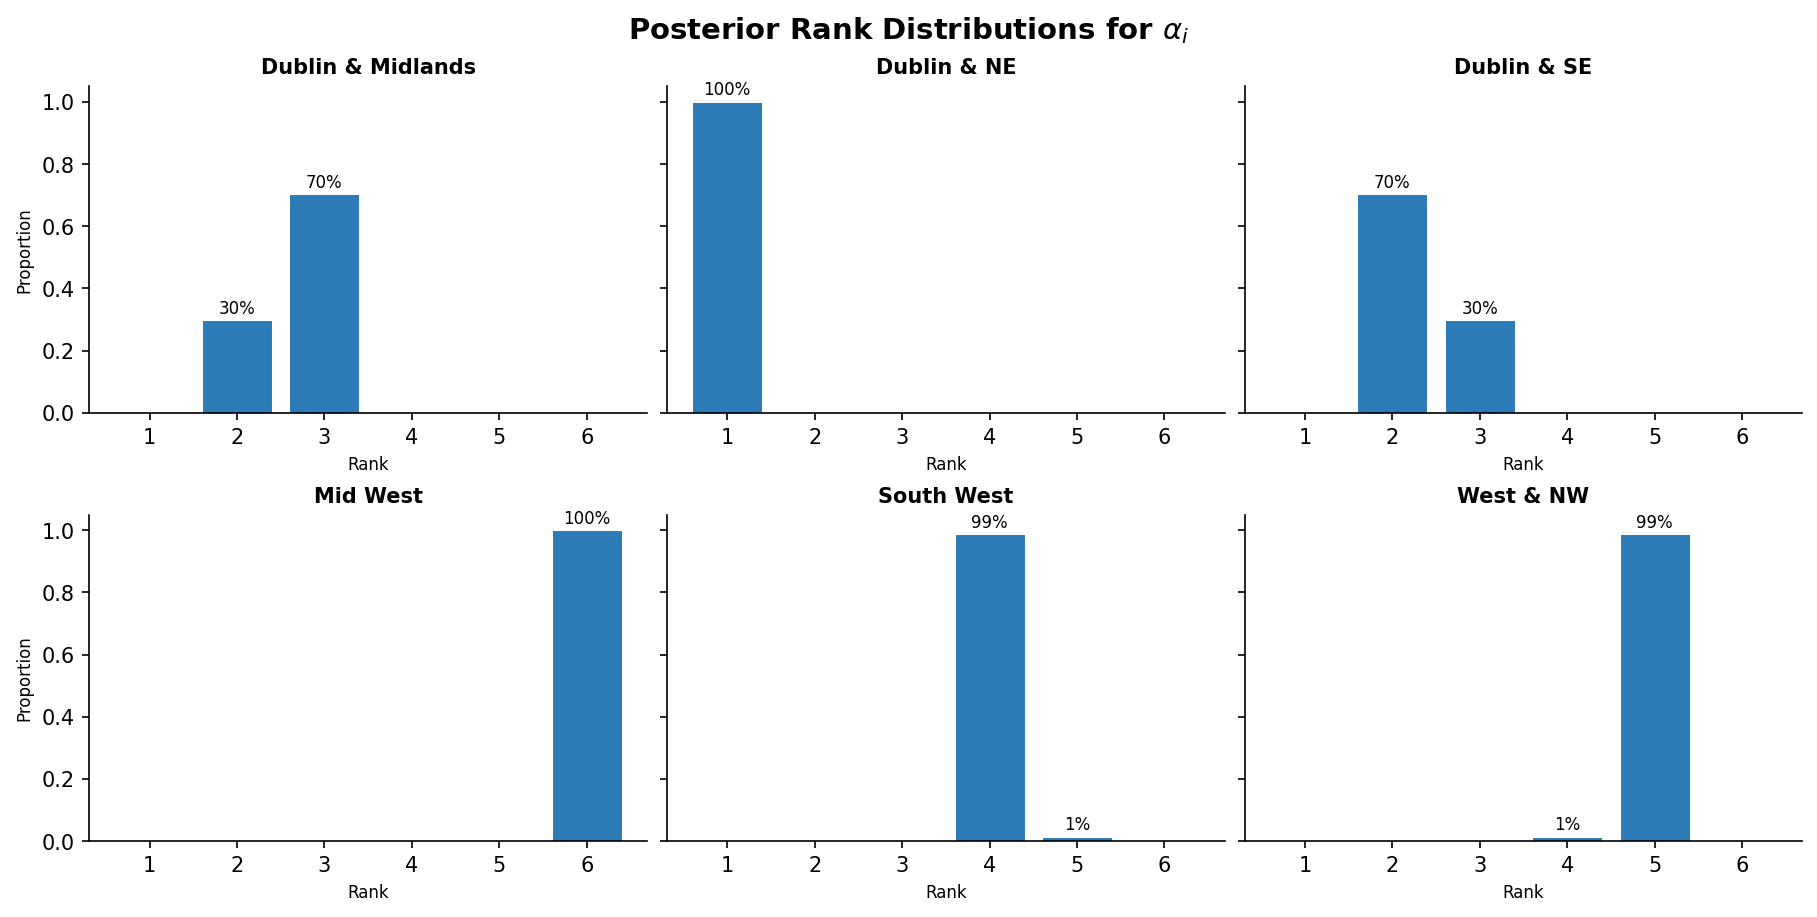

In [34]:
n_samples = len(ranked_alpha)
fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=150, layout='constrained', sharey=True)

for ax, col in zip(axes.flatten(), ranked_alpha.columns):
    counts = ranked_alpha[col].value_counts().reindex(range(1, 7), fill_value=0)
    props = counts / n_samples

    bars = ax.bar(range(1, 7), props, color='#2c7bb6', edgecolor='white', linewidth=0.5)

    for bar, p in zip(bars, props):
        if p > 0.005:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{p:.0%}', ha='center', va='bottom', fontsize=8)

    ax.set_title(SHORT_NAMES.get(col, col), fontsize=10, fontweight='600')
    ax.set_xlabel('Rank', fontsize=8)
    ax.set_xticks(range(1, 7))
    ax.set_ylabel('Proportion' if ax in axes[:, 0] else '', fontsize=8)
    sns.despine(ax=ax)

fig.suptitle(r'Posterior Rank Distributions for $\alpha_i$', fontsize=14, fontweight='bold')
fig.savefig(PLOT_DIR + 'ranks.png', bbox_inches='tight', dpi=150)
plt.show()

### Pairwise comparison

In [35]:
lower_q = .025; upper_q = .975
pairwise_test_df = []
for x in combinations(regions, 2):
    difference = ranked_alpha[x[0]] - ranked_alpha[x[1]]
    quantile = np.quantile(difference, [lower_q, upper_q])
    pairwise_test_df.append({
        'Region(1) - Region(2)': f"{x[0]} - {x[1]}",
        'Mean': difference.mean(),
        'Median': difference.median(),
        '2.5%': quantile[0],
        '97.5%': quantile[1],
        'P(Region(1) > Region(2))': round((difference > 0).mean(), 3),
        'P(Region(1) < Region(2))': round((difference < 0).mean(), 3),
    })
pd.DataFrame(pairwise_test_df)

,Region(1) - Region(2),Mean,Median,2.5%,97.5%,P(Region(1) > Region(2)),P(Region(1) < Region(2))
0,HSE Dublin and Midlands - HSE Dublin and North...,1.702975,2.0,1.0,2.0,1.000,0.000
1,HSE Dublin and Midlands - HSE Dublin and South...,0.405938,1.0,-1.0,1.0,0.703,0.297
2,HSE Dublin and Midlands - HSE Mid West,-3.297025,-3.0,-4.0,-3.0,0.000,1.000
3,HSE Dublin and Midlands - HSE South West,-1.309937,-1.0,-2.0,-1.0,0.000,1.000
4,HSE Dublin and Midlands - HSE West and North West,-2.284100,-2.0,-3.0,-2.0,0.000,1.000
5,HSE Dublin and North East - HSE Dublin and Sou...,-1.297038,-1.0,-2.0,-1.0,0.000,1.000
6,HSE Dublin and North East - HSE Mid West,-5.000000,-5.0,-5.0,-5.0,0.000,1.000
7,HSE Dublin and North East - HSE South West,-3.012913,-3.0,-3.0,-3.0,0.000,1.000
8,HSE Dublin and North East - HSE West and North...,-3.987075,-4.0,-4.0,-4.0,0.000,1.000
9,HSE Dublin and South East - HSE Mid West,-3.702962,-4.0,-4.0,-3.0,0.000,1.000
